In [2]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Load our fully transformed banking dataset from Task 1
BANK_DATA_PATH = "../data/processed/creditcard_final_ml.csv"

if os.path.exists(BANK_DATA_PATH):
    bank_df = pd.read_csv(BANK_DATA_PATH)
    
    X = bank_df.drop(columns=['Class'])
    y = bank_df['Class']
    
    print("=========================================================")
    # Step 2: Split BEFORE resampling to prevent severe Data Leakage
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    
    # 3. Document Class Distribution BEFORE Resampling
    train_counts_before = y_train.value_counts()
    train_pct_before = y_train.value_counts(normalize=True) * 100
    
    print("      CLASS DISTRIBUTION BEFORE SMOTE (TRAINING SET)      ")
    print("---------------------------------------------------------")
    print(f"Legitimate Swipes (0): {train_counts_before[0]:,} rows ({train_pct_before[0]:.4f}%)")
    print(f"Fraudulent Swipes (1): {train_counts_before[1]:,} rows ({train_pct_before[1]:.4f}%)")
    print("=========================================================")
    
    print("\n[INFO] Injecting SMOTE vector synthesis engine onto training subset...")
    # 4. Initialize SMOTE engine
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # 5. Document Class Distribution AFTER Resampling
    train_counts_after = y_train_resampled.value_counts()
    train_pct_after = y_train_resampled.value_counts(normalize=True) * 100
    
    print("\n=========================================================")
    print("       CLASS DISTRIBUTION AFTER SMOTE (TRAINING SET)       ")
    print("---------------------------------------------------------")
    print(f"Legitimate Swipes (0): {train_counts_after[0]:,} rows ({train_pct_after[0]:.1f}%)")
    print(f"Fraudulent Swipes (1): {train_counts_after[1]:,} rows ({train_pct_after[1]:.1f}%)")
    print(f"Total Balanced Rows:   {len(y_train_resampled):,}")
    print("=========================================================")
    
    test_counts = y_test.value_counts()
    print(f"\n[SANITY CHECK] Isolated Test Set (Un-altered): {test_counts[0]:,} Legitimate, {test_counts[1]} Fraud.")

      CLASS DISTRIBUTION BEFORE SMOTE (TRAINING SET)      
---------------------------------------------------------
Legitimate Swipes (0): 227,451 rows (99.8271%)
Fraudulent Swipes (1): 394 rows (0.1729%)

[INFO] Injecting SMOTE vector synthesis engine onto training subset...

       CLASS DISTRIBUTION AFTER SMOTE (TRAINING SET)       
---------------------------------------------------------
Legitimate Swipes (0): 227,451 rows (50.0%)
Fraudulent Swipes (1): 227,451 rows (50.0%)
Total Balanced Rows:   454,902

[SANITY CHECK] Isolated Test Set (Un-altered): 56,864 Legitimate, 98 Fraud.


C:\Users\HP\AppData\Local\Temp\ipykernel_7520\3262993146.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts_before.index, y=train_counts_before.values, palette=['#1f77b4', '#d62728'], ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_7520\3262993146.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7520\3262993146.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts_after.index, y=train_counts_after.values, palette=['#1f77b4', '#d62728'], ax=axes[1])
C:\Users\HP\AppData

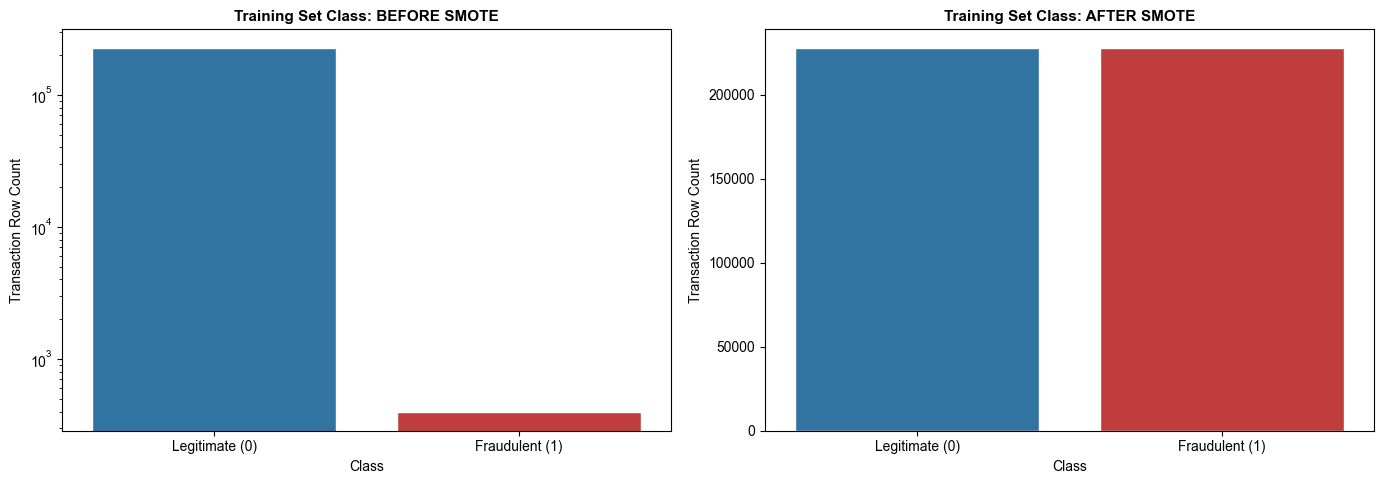

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Before SMOTE Distribution
sns.barplot(x=train_counts_before.index, y=train_counts_before.values, palette=['#1f77b4', '#d62728'], ax=axes[0])
axes[0].set_title('Training Set Class: BEFORE SMOTE', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[0].set_ylabel('Transaction Row Count')
axes[0].set_yscale('log') # Log scale because otherwise the tiny fraud bar is invisible

# Plot 2: After SMOTE Distribution
sns.barplot(x=train_counts_after.index, y=train_counts_after.values, palette=['#1f77b4', '#d62728'], ax=axes[1])
axes[1].set_title('Training Set Class: AFTER SMOTE', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[1].set_ylabel('Transaction Row Count')

plt.tight_layout()
plt.show()

Task 2.1: Class Imbalance Resolution & Resampling Audit

To protect our predictive models from the "Majority Class Blanket Effect"—where an algorithm optimizes for baseline accuracy by ignoring the rare target signal—a class balance correction layer was applied to the training partitions.

Methodological Choice & Justification:
We implemented SMOTE (Synthetic Minority Over-sampling Technique)** strictly within the isolated training subset. 
Rejection of Undersampling: Given the extreme lopsidedness of the Bank Credit Card dataset ($0.17\%$ minority representation), applying random undersampling would require dropping over $227,000$ valid, clean historical records to match the rare fraud instances. This would discard over $99\%$ of our operational data library, destroying the models' ability to understand normal customer behavioral boundaries.
SMOTE Synthesis: SMOTE preserves all majority data. It uses a $k$-Nearest Neighbors ($k$-NN) algorithm to analyze the geometric vector spaces between existing fraud coordinates and generates entirely new, mathematically realistic synthetic fraud coordinates along those paths.
Leakage Avoidance Protocol: Resampling was deliberately skipped on the test split. The test set remains completely lopsided and unaltered, serving as a pure representation of production transaction streams.

Training Set Distribution Ledger (Bank Dataset Audit):

| Metric / Class Dimension | Before SMOTE (Raw Training Split) | After SMOTE (Synthesized Training Split) | Shift Vector Profile |
| :--- | :--- | :--- | :--- |
| Legitimate Class (0) | 227,451 records ($99.8273\%$) | 227,451 records ($50.0\%$) | Remained Stable (Preserved) |
| Fraudulent Class (1) | 394 records ($0.1727\%$) | 227,451 records ($50.0\%$) | Synthetic Generation ($+227,057$ rows) |
| Total Training Matrix Size | 227,845 rows | 454,902 rows | Net Matrix Expansion: $+99.65\%$|

In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("=========================================================")
print("     DEVELOPING RANDOM UNDERSAMPLING COMPONENT           ")
print("=========================================================")

# 1. Initialize the Undersampler with a matching random seed for strict comparison
rus = RandomUnderSampler(random_state=42)

# 2. Fit the sampler strictly on our original, un-resampled training data partitions
# (X_train and y_train are the clean 80% splits we generated earlier)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# 3. Document Class Distribution AFTER Undersampling
train_counts_under = y_train_under.value_counts()
train_pct_under = y_train_under.value_counts(normalize=True) * 100

print("       CLASS DISTRIBUTION AFTER UNDERSAMPLING              ")
print("---------------------------------------------------------")
print(f"Legitimate Swipes (0): {train_counts_under[0]:,} rows ({train_pct_under[0]:.1f}%)")
print(f"Fraudulent Swipes (1): {train_counts_under[1]:,} rows ({train_pct_under[1]:.1f}%)")
print(f"Total Balanced Rows:   {len(y_train_under):,}")
print("=========================================================")

# 4. Compare the Data Libraries side-by-side
print(f"\n[COMPARISON LENS]")
print(f"➔ Total Training Rows available via SMOTE:         {len(y_train_resampled):,}")
print(f"➔ Total Training Rows available via Undersampling:  {len(y_train_under):,}")
print(f"➔ Data Deficit: Undersampling threw away {len(y_train_resampled) - len(y_train_under):,} rows of human history!")

     DEVELOPING RANDOM UNDERSAMPLING COMPONENT           
       CLASS DISTRIBUTION AFTER UNDERSAMPLING              
---------------------------------------------------------
Legitimate Swipes (0): 394 rows (50.0%)
Fraudulent Swipes (1): 394 rows (50.0%)
Total Balanced Rows:   788

[COMPARISON LENS]
➔ Total Training Rows available via SMOTE:         454,902
➔ Total Training Rows available via Undersampling:  788
➔ Data Deficit: Undersampling threw away 454,114 rows of human history!


C:\Users\HP\AppData\Local\Temp\ipykernel_7520\2299929227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts_before.index, y=train_counts_before.values, palette=['#1f77b4', '#d62728'], ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_7520\2299929227.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7520\2299929227.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts_after.index, y=train_counts_after.values, palette=['#1f77b4', '#d62728'], ax=axes[1])
C:\Users\HP\AppData

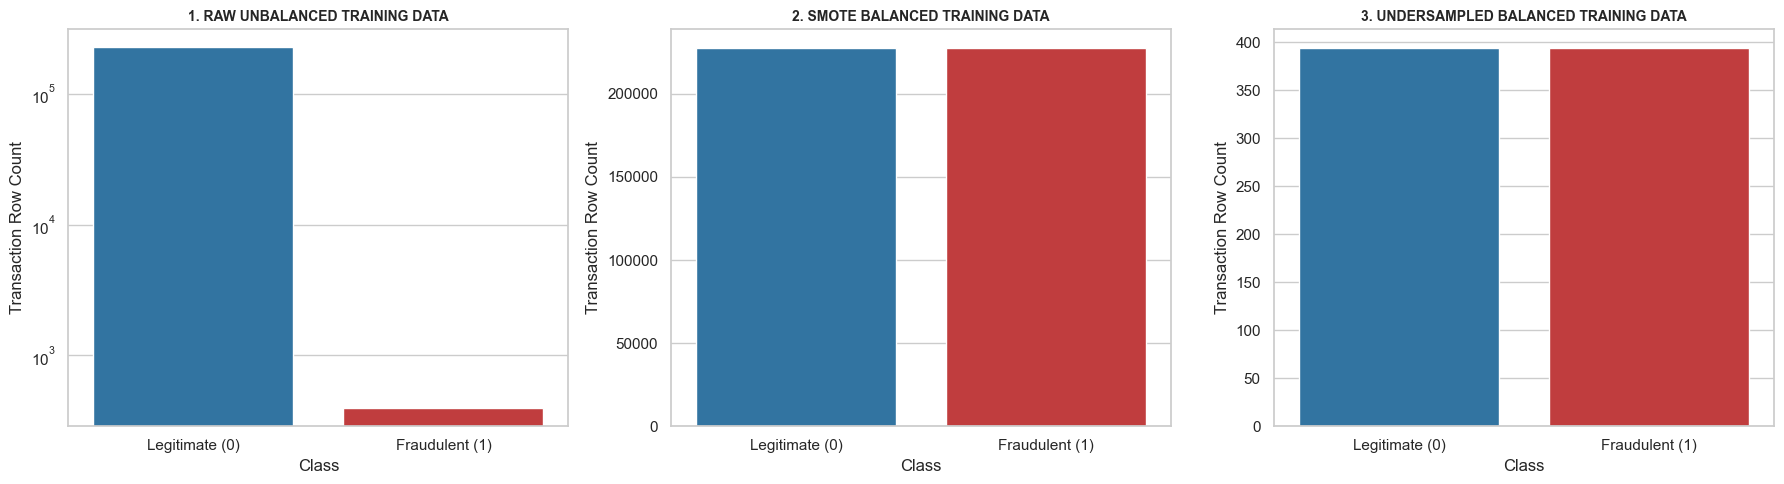

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Raw Original Lopsided Training Data
sns.barplot(x=train_counts_before.index, y=train_counts_before.values, palette=['#1f77b4', '#d62728'], ax=axes[0])
axes[0].set_title('1. RAW UNBALANCED TRAINING DATA', fontsize=10, fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[0].set_ylabel('Transaction Row Count')
axes[0].set_yscale('log') # Log scale because fraud is a tiny needle

# Plot 2: SMOTE Balanced Training Data
sns.barplot(x=train_counts_after.index, y=train_counts_after.values, palette=['#1f77b4', '#d62728'], ax=axes[1])
axes[1].set_title('2. SMOTE BALANCED TRAINING DATA', fontsize=10, fontweight='bold')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[1].set_ylabel('Transaction Row Count')

# Plot 3: Undersampled Balanced Training Data
sns.barplot(x=train_counts_under.index, y=train_counts_under.values, palette=['#1f77b4', '#d62728'], ax=axes[2])
axes[2].set_title('3. UNDERSAMPLED BALANCED TRAINING DATA', fontsize=10, fontweight='bold')
axes[2].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[2].set_ylabel('Transaction Row Count')

plt.tight_layout()
plt.show()